# Tracey letlape | LTLTRA001 | CSC3042F | A2

### AI Usage Statement

I used ChatGPT to help with the following:
* Clarify the assignment requirements
* Debug PyTorch dimension errors
* Improve my implementation of Seq2Seq training, greedy decoding and analysis sections.
* I reviewed, tested, and adapted the results myself, and I take responsibility for the final notebook and results. 

#### Imports and Necessary Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import random

import kagglehub

from collections import Counter
from nltk.metrics.distance import edit_distance

### Define seeds for deterministic behaviour & Define a device

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')
print(f"Number of GPUs: {torch.cuda.device_count() if torch.cuda.is_available() else 0}")

Using device: cuda
PyTorch version: 2.10.0+cu128
Number of GPUs: 2


## 1. Data Processing

### a. Building character and phoneme vocabulary from training data
* Define a *read_raw_data* function that takes a file_name as input and returns a DataFrame of the words and phonemes.
* Define a *build_vocab* function that builds a vocab depending on the bool value of the *char* and *phoneme* function parameters.
    * Vocab is represented as a dictionary of characters/phonesmes as strings and integers as values

In [4]:
# Download latest version
DATA_DIR = kagglehub.dataset_download("kevinchiloane/a2-dataset")

In [5]:
# Define workser_seed for deterministic behaviour
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def read_raw_data(file_name: str) -> pd.DataFrame:
    """
    Read the data from the file_name with the assumption that the file is a csv_file.
    Parameters:
        file_name: Name of a CSV file 
    Returns:
        df: DataFrame of the words and phonemes
    """
    file_path = os.path.join(DATA_DIR, file_name)
    df = pd.read_csv(file_path)
    return df

def build_vocab(data_df: pd.DataFrame, char: bool = True, phoneme: bool = False) -> dict:
    """
    Builds a vocabulary depending on the bool value of char and phoneme parameters.
    If both char and phoneme are true, returns a vocab with only the special tokens.
    Parameters:
        data_df: Represents the DataFrame of the words and phonemes
        char: Builds a char_vocab if True
        phoneme: Builds a phoneme_vocab if True
    Returns:
        vocab: A dictionary of a word/phoneme as key and index as value
    """
    vocab = {
        "<PAD>": 0,
        "<SOS>": 1,
        "<EOS>": 2,
        "<UNK>": 3
    }
    idx = 4
    if char:
        words = data_df['word'].dropna().astype(str).tolist()
        for word in words:
            idx = _build_char_vocab_helper(word, vocab, idx)
    elif phoneme:
        phonemes = data_df['phonemes'].dropna().astype(str).tolist()
        for ph in phonemes:
            ph = ph.split(" ")
            idx = _build_phoneme_vocab_helper(ph, vocab, idx)
    return vocab
    

def _build_char_vocab_helper(word: str, vocab: dict[str, int], idx: int) -> int:
    for c in word:
        if c not in vocab:
            vocab[c] = idx
            idx += 1
    return idx

def _build_phoneme_vocab_helper(phonemes: list[str], vocab: dict[str, int], idx: int) -> int:
    for phoneme in phonemes:
        if phoneme not in vocab:
            vocab[phoneme] = idx
            idx += 1
    return idx


### b. Implementation of a PyTorch Dataset class that for encoding (word, phoneme) pairs as integer index sequences


In [6]:
class WPDataset(Dataset):
    def __init__(self, pairs: list[tuple[str, str]], chr_vocab: dict[str, int], ph_vocab: dict[str, int]):
        self.pairs: list[tuple[str, str]] = pairs
        self.chr_vocab: dict[str, int] = chr_vocab
        self.ph_vocab: dict[str, int] = ph_vocab

        self._cache: dict[int, tuple[list[int], list[int]]] = {}

    def __len__(self) -> int:
        """
        Returns the length of the dataset.
        """
        return len(self.pairs)
    
    def __getitem__(self, idx: int) -> tuple[list[int], list[int]]:
        """
        Returns the encoded pair at the given index
        Parameters:
            idx: Represents an index
        Returns:
            enc_word, enc_phoneme
        """
        if idx not in self._cache:
            word, phoneme = self.pairs[idx]
            self._cache[idx] = self.encode_pair(word, phoneme)
        return self._cache[idx]

    def encode_pair(self, word: str, phoneme: str) -> tuple[list[int], list[int]]:
        """
        Encodes the given word and phoneme pair
        Parameters:
            word: Represents a word in the dataset.
            phoneme: Represents a phoneme corresponding to the word.
        Returns:
            enc_word, enc_phoneme
        """
        word_enc = []
        phoneme_enc = [self.ph_vocab["<SOS>"]]

        self._encode_word(word, self.chr_vocab, word_enc)
        self._encode_phoneme(phoneme.split(" "), self.ph_vocab, phoneme_enc)

        return word_enc, phoneme_enc
    
    def decode_pair(self, enc_word: list[int], enc_ph: list[int]) -> tuple[str, str]:
        """
        Decodes the given encoded word and phoneme pairs
        Parameters:
            enc_word: Represent a word encoded as integer sequences
            enc_ph: Represent a phoneme encoded as integer sequences
        Returns:
            dec_word, dec_ph
        """
        # Invert the vocabs
        inv_chr_vocab: dict[int, str] = {v: k for k, v in self.chr_vocab.items()}
        inv_ph_vocab: dict[int, str] = {v: k for k, v in self.ph_vocab.items()}

        dec_word = self._decode_word(enc_word, inv_chr_vocab)
        dec_ph = self._decode_phoneme(enc_ph, inv_ph_vocab)
        
        return dec_word, dec_ph

    def _encode_word(self, word: str, chr_vocab: dict, int_seq: list) -> None:
        for c in word:
            int_seq.append(self.chr_vocab.get(c, chr_vocab["<UNK>"]))

    def _encode_phoneme(self, phoneme: list, ph_vocab: dict[str, int], int_seq: list[int]) -> None:
        for ph in phoneme:
            int_seq.append(ph_vocab.get(ph, ph_vocab["<UNK>"]))
        int_seq.append(ph_vocab["<EOS>"])

    def _decode_word(self, enc_word: list, inv_chr_vocab: dict[int, str]) -> str:
        cleaned_ids = self._clean_tokens(enc_word)
        return "".join(inv_chr_vocab[idx] for idx in cleaned_ids)
    
    def _decode_phoneme(self, enc_ph: list[int], inv_ph_vocab: dict[int, str]) -> str:
        cleaned_ids = self._clean_tokens(enc_ph)
        return " ".join(inv_ph_vocab[idx] for idx in cleaned_ids)
    
    def _clean_tokens(self, token_ids):
        cleaned = []

        for idx in token_ids:
            idx = int(idx)

            if idx in [0, 1]:
                continue

            if idx == 2:
                break

            cleaned.append(idx)

        return cleaned

### c. Implement collate_fn and create DataLoaders with padding

In [7]:
def _pad_sequences(sequences: list, pad_value: int = 0) -> torch.Tensor:
    """
    Sequences: list of 1D lists
    """
    max_len = max(len(seq) for seq in sequences)

    padded_sequences = []
    for seq in sequences:
        seq = torch.tensor(seq)
        pad_length = max_len - len(seq)

        padding = torch.full(
            (pad_length,),
            pad_value,
            dtype=seq.dtype
        )

        padded_seq = torch.cat([seq, padding])
        padded_sequences.append(padded_seq)

    return torch.stack(padded_sequences)

def collate_fn(batch):
    """
    Batch is a list of samples from the Dataset.
    Example:
        [
            ([5, 4, 6], [1, 5, 4, 6, 2]),
            ([7, 4],    [1, 7, 8, 2])
        ]
    """
    sources = [item[0] for item in batch]
    targets = [item[1] for item in batch]

    sources_padded = _pad_sequences(sources)
    targets_padded = _pad_sequences(targets)

    return sources_padded, targets_padded

In [8]:
# Data files
TRAIN_FILE_NAME = "g2p_train.csv"
VAL_FILE_NAME = "g2p_val.csv"
TEST_FILE_NAME = "g2p_test.csv"

# Read the raw data
train_df = read_raw_data(TRAIN_FILE_NAME)
val_df = read_raw_data(VAL_FILE_NAME)
test_df = read_raw_data(TEST_FILE_NAME)

# Build the vocabs
chr_vocab = build_vocab(train_df)
ph_vocab = build_vocab(train_df, char=False, phoneme=True)

# Get the pairs
train_pairs = list(zip(train_df["word"].dropna().astype(str), train_df["phonemes"].dropna().astype(str)))
val_pairs = list(zip(val_df["word"].dropna().astype(str), val_df["phonemes"].dropna().astype(str)))
test_pairs = list(zip(test_df["word"].dropna().astype(str), test_df["phonemes"].dropna().astype(str)))

# Define WPDatasets
train_dataset = WPDataset(train_pairs, chr_vocab, ph_vocab)
val_dataset = WPDataset(val_pairs, chr_vocab, ph_vocab)
test_dataset = WPDataset(test_pairs, chr_vocab, ph_vocab)

In [9]:
# Define generator for deterministic shuffling
generator = torch.Generator()
generator.manual_seed(SEED)

# Define DataLoaders
train_dataloader = DataLoader(
    train_dataset, 
    batch_size=256, 
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=True,
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=generator
)
val_dataloader = DataLoader(
    val_dataset, 
    batch_size=128, 
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=True,
    num_workers=2,
    worker_init_fn=seed_worker
)
test_dataloader = DataLoader(
    test_dataset, 
    batch_size=128, 
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=True,
    num_workers=2,
    worker_init_fn=seed_worker
)

In [10]:
# Dataset sizes
print(f"Train Dataset size = {len(train_dataset)}")
print(f"Val Dataset size = {len(val_dataset)}")
print(f"Test Dataset size = {len(test_dataset)}")

# Vocabulary Sizes
print()
print(f"Character vocab size = {len(chr_vocab)}")
print(f"Phoneme vocab size = {len(ph_vocab)}")

Train Dataset size = 92424
Val Dataset size = 11553
Test Dataset size = 11554

Character vocab size = 30
Phoneme vocab size = 73


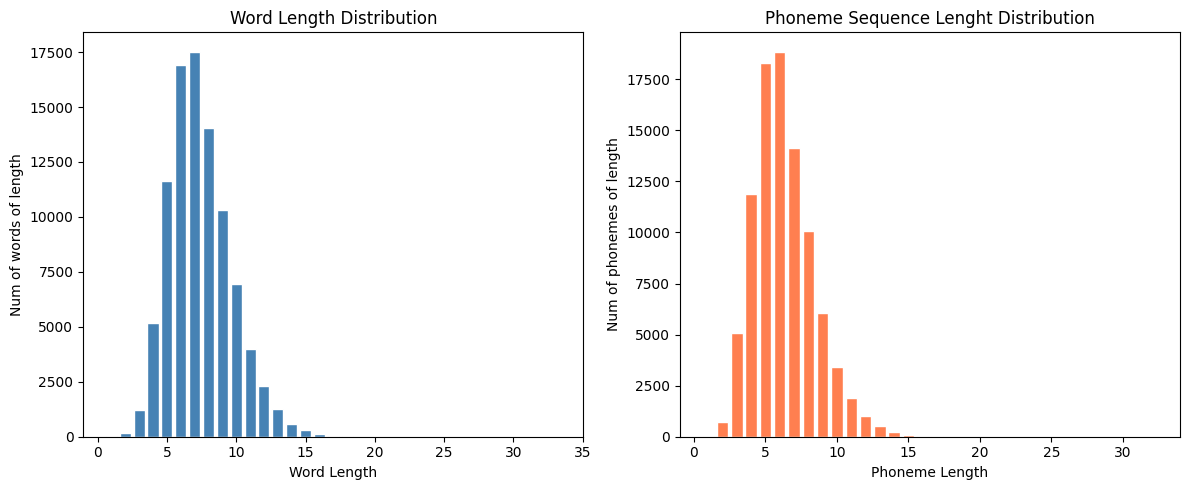

In [11]:
# Get the lenghts for raw inputs
wd_len_counts = Counter(len(word) for word, _ in train_dataset.pairs)
ph_len_counts = Counter(len(ph.split(" ")) for _, ph in train_dataset.pairs)

# Sort by length
wd_len_counts = dict(sorted(wd_len_counts.items()))
ph_len_counts = dict(sorted(ph_len_counts.items()))

# Plot the Words and Phonemes Length Distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(wd_len_counts.keys(), wd_len_counts.values(), color="steelblue", edgecolor="white")
axes[0].set_title("Word Length Distribution")
axes[0].set_xlabel("Word Length")
axes[0].set_ylabel("Num of words of length")

axes[1].bar(ph_len_counts.keys(), ph_len_counts.values(), color="coral", edgecolor="white")
axes[1].set_title("Phoneme Sequence Lenght Distribution")
axes[1].set_xlabel("Phoneme Length")
axes[1].set_ylabel("Num of phonemes of length")

plt.tight_layout()
plt.show()

## 2. LSTM cell

In [12]:
# Tutorial 3 Implementation
# @author Francois Meyer

class LSTMCell(nn.Module):
    """
    Single LSTM cell implementing the six gating equations.
    params:
        input_size:  dimensionality of input x_t
        hidden_size: dimensionality of hidden state h_t and cell state c_t
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_size = input_size
        
        # Forget gate
        self.W_f = nn.Linear(input_size, hidden_size, bias=False)
        self.U_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_f = nn.Parameter(torch.zeros(hidden_size))
    
        # Input gate
        self.W_i = nn.Linear(input_size, hidden_size, bias=False)
        self.U_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_i = nn.Parameter(torch.zeros(hidden_size))
       
        # Output gate
        self.W_o = nn.Linear(input_size, hidden_size, bias=False)
        self.U_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_o = nn.Parameter(torch.zeros(hidden_size))

        # Cell content
        self.W_c = nn.Linear(input_size, hidden_size, bias=False)
        self.U_c = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_c = nn.Parameter(torch.zeros(hidden_size))
        


    def forward(self, x, h_prev, c_prev):
        """
        Compute one LSTM timestep.
        params:
            x:      input at current timestep, shape (batch, input_size)
            h_prev: previous hidden state,     shape (batch, hidden_size)
            c_prev: previous cell state,       shape (batch, hidden_size)
        returns:
            h: new hidden state, shape (batch, hidden_size)
            c: new cell state,   shape (batch, hidden_size)
        """
        # Apply gate activations
        i_t = torch.sigmoid(self.W_f(x) + self.U_f(h_prev) + self.b_f)    # input gate
        f_t = torch.sigmoid(self.W_i(x) + self.U_i(h_prev) + self.b_i)    # Forget gate
        o_t = torch.sigmoid(self.W_o(x) + self.U_o(h_prev) + self.b_o)       # candidate memory
        c_tilde = torch.tanh(self.W_c(x) + self.U_c(h_prev) + self.b_c)    # Output gate

        # Update cell state
        c_next = f_t * c_prev + i_t * c_tilde

        # Update hiddem state
        h_next = o_t * torch.tanh(c_next)

        return h_next, c_next

## 3. Encoder-decoder Implementation

In [13]:
# @author Francois Meyer
class Encoder(nn.Module):
    def __init__(self, src_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(
            num_embeddings=src_vocab_size, 
            embedding_dim=embed_dim, 
            padding_idx=0
        )
        
        self.cell = LSTMCell(
            input_size=embed_dim,
            hidden_size=hidden_size
        )


    def forward(self, src):
        """
        Parameters:
            src: token indices, shape (batch, src_len)
        Returns:
            all_h: shape (src_len, batch, hidden_size),
            h_n, c_n: shape (num_layers, batch, hidden_size)
        """
        batch_size, seq_len = src.shape
        
        emb = self.embedding(src)    # (batch_size, seq_len, embed_dim)
        
        h = torch.zeros(batch_size, self.hidden_size, device=src.device)

        c = torch.zeros(batch_size, self.hidden_size, device=src.device)

        all_h = []
        for t in range(seq_len):
            x_t = emb[:, t, :]         # x shape: (batch_size, emd_dim) for first layer

            h, c = self.cell(x_t, h, c)
            
            all_h.append(h)

        all_h = torch.stack(all_h, dim=0)

        h_n = h.unsqueeze(0)
        c_n = c.unsqueeze(0)

        return all_h, (h_n, c_n)

In [14]:
class Decoder(nn.Module):
    def __init__(self, tgt_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1, context_mode: str = "none"):
        super().__init__()

        modes = ["none", "fixed", "attn"]

        if context_mode not in modes:
            raise ValueError(f"context mode must be in {modes}")
        
        self.tgt_vocab_size = tgt_vocab_size
        self.embed_dim = embed_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.context_mode = context_mode

        self.embedding = nn.Embedding(
            num_embeddings=tgt_vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        if context_mode == "none":
            cell_input_size = embed_dim
        else:
            cell_input_size = embed_dim + hidden_size

        self.cell = LSTMCell(
            input_size=cell_input_size,
            hidden_size=hidden_size
        )

        self.fc = nn.Linear(hidden_size, tgt_vocab_size)

    def forward(self, tgt: torch.Tensor, hidden: torch.Tensor, encoder_outputs: torch.Tensor | None=None):
        """
        Parameters:
            tgt: (batch, tgt_len)
            hidden: (h_0, c_0)
                h_0, c_0: (num_layers, batch, hidden_size)
            encoder_outputs: needed only for attention
                (src_len, batch, hidden_size)
        Returns:
            (logits, (h_n, c_n))
                logits: (batch, tgt_len, tgt_vocab_size)
                h_n, c_n: (num_layers, batch, hidden_size)
        """
        _, tgt_len = tgt.shape

        h_0, c_0 = hidden

        h, c = h_0[0], c_0[0]

        # Fixed context = initial hidden state from encode
        fixed_context = h

        embedded = self.embedding(tgt)

        logits_list = []


        if self.context_mode == "attn":
            if encoder_outputs is None:
                raise ValueError("encoder_outputs cannot be none when context_mode=attn")
                
            encoder_outputs = encoder_outputs.transpose(0, 1)

        for t in range(tgt_len):
            x_t = embedded[:, t, :]
            cell_input = None

            if self.context_mode == "none":
                cell_input = x_t

            elif self.context_mode == "fixed":
                cell_input  = torch.cat([x_t, fixed_context], dim=-1)

            elif self.context_mode == "attn":
                scores = torch.bmm(encoder_outputs, h.unsqueeze(2)).squeeze(2) # type: ignore

                attn_weights = F.softmax(scores, dim=1)

                context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1) # type: ignore
                cell_input = torch.cat([x_t, context], dim=-1)
            
            h, c = self.cell(cell_input, h, c)
            logits_list.append(self.fc(h))

        logits = torch.stack(logits_list, dim=1)

        h_n, c_n = h.unsqueeze(0), c.unsqueeze(0)

        return logits, (h_n, c_n)


In [15]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()

        self.SOS_IDX = 1
        self.EOS_IDX = 2

        self.encoder = encoder
        self.decoder = decoder


    def forward(self, src: torch.Tensor, tgt: torch.Tensor, teacher_forcing: bool = True):
        encoder_outputs, encoder_hidden = self.encoder(src)

        if teacher_forcing:
            logits, _ = self.decoder(tgt, encoder_hidden, encoder_outputs)
            return logits
        
        else:
            _, tgt_len = tgt.shape

            hidden = encoder_hidden

            current_token = tgt[:, 0].unsqueeze(1)

            logits_list = []

            for _ in range(tgt_len -1):
                logits_step, hidden = self.decoder(current_token, hidden, encoder_outputs)
                logits_list.append(logits_step)

                # Greedy prediction
                next_token = logits_step[:, -1, :].argmax(dim=1)
                current_token = next_token.unsqueeze(1)

            logits = torch.cat(logits_list, dim=1)
            return logits
        
    def greedy_decode(self, src: torch.Tensor, max_len: int = 30):
        batch_size = src.size(0)
        device = src.device

        encoder_outputs, hidden = self.encoder(src)

        current_token = torch.full(
            size=(batch_size, 1),
            fill_value=self.SOS_IDX,
            dtype=torch.long,
            device=device
        )

        predictions = []

        # Fixed token for fixed context_mode
        if self.decoder.context_mode == 'fixed':
            generated = current_token

            for _ in range(max_len):
                logits_step, _ = self.decoder(generated, hidden, encoder_outputs)

                next_token = logits_step[:, -1, :].argmax(dim=1)
                predictions.append(next_token)

                generated = torch.cat([generated, next_token.unsqueeze(1)], dim=1)

                if torch.all(next_token == self.EOS_IDX):
                    break

            predictions = torch.stack(predictions, dim=1)
            return predictions


        for _ in range(max_len):
            logits_step, hidden = self.decoder(current_token, hidden, encoder_outputs)

            next_token = logits_step[:, -1, :].argmax(dim=1)
            predictions.append(next_token)

            current_token = next_token.unsqueeze(1)

            # Stop early only if every sequence predicted <EOS>
            if torch.all(next_token == self.EOS_IDX):
                break

        predictions = torch.stack(predictions, dim=1)
        return predictions

### 4. Training
    * Train each model with cross-entropy loss and Adam optimiser

In [16]:
# Global vals across all models
SRC_VOCAB_SIZE = len(chr_vocab)
TGT_VOCAB_SIZE = len(ph_vocab)
EMB_DIM = 32
HIDDEN_SIZE = 64

In [17]:
def train(model, loader, criterion, optimiser):
    # Move model to device
    model.to(DEVICE)

    # Set model to train mode
    model.train()

    total_correct, total_tokens, total_loss = 0, 0, 0.0

    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        # Exclude the <EOS> token from decoder input
        tgt_input = tgt[:, :-1]

        # Exclude the <SOS> token from expected output
        tgt_output = tgt[:, 1:]

        # Zero grad
        optimiser.zero_grad()

        # Forward pass
        logits = model(src, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
        
        # Back prop
        loss.backward()

        # Clip gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimiser.step()

        # Count non-padding tokens for average loss
        non_pad_mask = tgt_output != 0
        non_pad_tokens = non_pad_mask.sum().item()

        total_loss += loss.item() * non_pad_tokens

        total_correct += ((logits.argmax(dim=-1) == tgt_output) & non_pad_mask).sum().item()
        total_tokens += non_pad_tokens

    return (total_loss / total_tokens), (total_correct / total_tokens)

def evaluate(model, loader, criterion):
    # Move model to device
    model.to(DEVICE)
    
    # Set the model to evaluation mode
    model.eval()

    total_loss, total_correct, total_tokens = 0.0, 0, 0

    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)

            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            # Forward pass
            logits = model(src, tgt_input)
         
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))

           # Count non-padding tokens for average loss
            non_pad_mask = tgt_output != 0
            non_pad_tokens = non_pad_mask.sum().item()

            total_loss += loss.item() * non_pad_tokens

            total_correct += ((logits.argmax(dim=-1) == tgt_output) & non_pad_mask).sum().item()
            total_tokens += non_pad_tokens

    return (total_loss / total_tokens), (total_correct / total_tokens)

In [18]:
def train_model(model, train_loader: DataLoader, val_loader: DataLoader, lr: float=1e-4, num_epochs=10):
    # Define the criterion and the optimiser
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimiser = optim.Adam(model.parameters(), lr=lr)

    # Patience limit to stop training when there is no improvement
    PATIENCE = 5

    # Metrics to track performance
    best_val_loss = float('inf')
    epochs_no_improve = 0

    # Store metrics
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
    }

    # Move model to device
    model.to(DEVICE)

    for epoch in range(num_epochs):
        tr_loss, tr_acc = train(model, train_loader, criterion, optimiser)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0       # Reset
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

    return model, history

In [19]:
def plot_results(nc_hist, fc_hist, ac_hist):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(nc_hist['train_loss'], label='None - Train loss')
    ax1.plot(nc_hist['val_loss'],   label='None - Val loss')

    ax1.plot(fc_hist['train_loss'], label='Fixed - Train loss')
    ax1.plot(fc_hist['val_loss'],   label='Fixed - Val loss')

    ax1.plot(ac_hist['train_loss'], label='Attention - Train loss')
    ax1.plot(ac_hist['val_loss'],   label='Attention - Val loss')

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-entropy loss')
    ax1.set_title(f'Loss curves')
    ax1.legend()

    ax2.plot(nc_hist['train_acc'], label='None - Train accuracy')
    ax2.plot(nc_hist['val_acc'], label='None - accuracy')

    ax2.plot(fc_hist['train_acc'], label='Fixed - Train accuracy')
    ax2.plot(fc_hist['val_acc'], label='Fixed - accuracy')

    ax2.plot(ac_hist['train_acc'], label='Attention - Train accuracy')
    ax2.plot(ac_hist['val_acc'], label='Attention - accuracy')

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'Accuracy Curves')
    ax2.legend()

    plt.tight_layout()
    plt.show()

#### a. Train No Context Model

In [20]:
# Define no context decoder and encoder
nc_encoder = Encoder(SRC_VOCAB_SIZE, EMB_DIM, HIDDEN_SIZE)
nc_decoder = Decoder(TGT_VOCAB_SIZE, EMB_DIM, HIDDEN_SIZE)

# Define no context Seq2Seq model
nc_model = Seq2Seq(nc_encoder, nc_decoder)

_, nc_hist = train_model(nc_model, train_dataloader, val_dataloader)


#### b. Train Fixed Context Model

In [21]:
# Define fixed context decoder and encoder
fc_encoder = Encoder(SRC_VOCAB_SIZE, EMB_DIM, HIDDEN_SIZE)
fc_decoder = Decoder(TGT_VOCAB_SIZE, EMB_DIM, HIDDEN_SIZE, context_mode='fixed')

# Define fixed context Seq2Seq model
fc_model = Seq2Seq(fc_encoder, fc_decoder)

_, fc_hist = train_model(fc_model, train_dataloader, val_dataloader)


#### c. Train Attention Context Model

In [22]:
# Define fixed context decoder and encoder
ac_encoder = Encoder(SRC_VOCAB_SIZE, EMB_DIM, HIDDEN_SIZE)
ac_decoder = Decoder(TGT_VOCAB_SIZE, EMB_DIM, HIDDEN_SIZE, context_mode='attn')

# Define fixed context Seq2Seq model
ac_model = Seq2Seq(ac_encoder, ac_decoder)

_, ac_hist = train_model(ac_model, train_dataloader, val_dataloader)


#### Plot Training Results

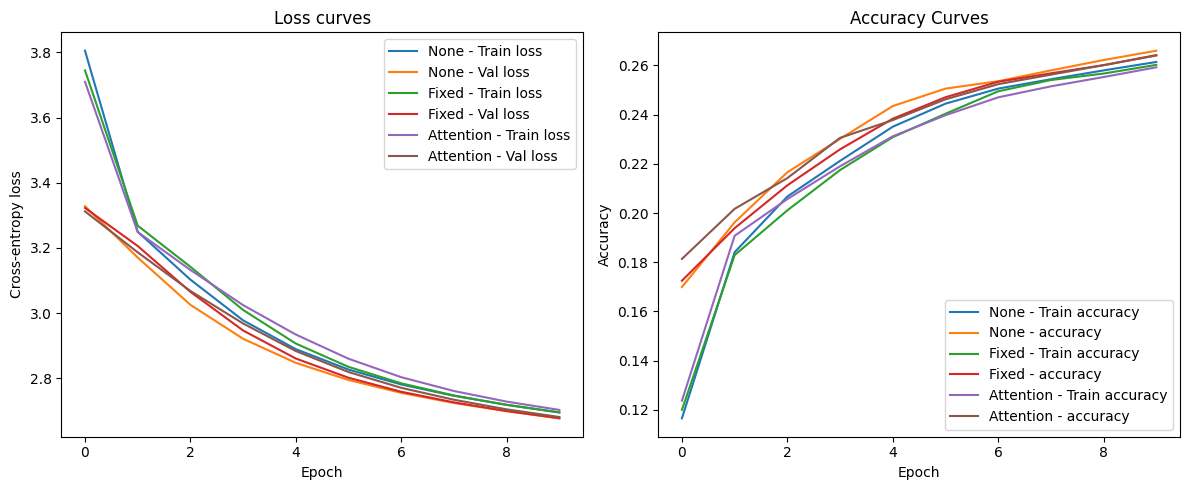

In [23]:
# Plot results
plot_results(nc_hist, fc_hist, ac_hist)

### 5. Hyperparameter tuning
* #### Using Setup 1: No Context Model
* #### Tune on the validation set (report val_loss and val_acc)
* Represent results in DataFrame

In [24]:
# Define hyperparameters
LRS = [1e-3, 1e-5]
EMB_DIMS = [64, 128]
HIDDEN_SIZES = [128, 256]

In [25]:
def tuning(train_loader, val_loader, lrs, emb_dims, hidden_sizes):
    # Performance Metrics
    results = {
        'lr': [],
        'emb_dim': [],
        'hidden_size': [],
        'val_loss': [],
        'val_acc': []
    }

    # Hyperparameter Search
    for emb_dim in emb_dims:
        for hidden_size in hidden_sizes:
            for lr in lrs:

                encoder = Encoder(SRC_VOCAB_SIZE, emb_dim, hidden_size)
                decoder = Decoder(TGT_VOCAB_SIZE, emb_dim, hidden_size)

                model = Seq2Seq(encoder, decoder)
                trained_model, hist = train_model(model, train_loader, val_loader, lr=lr, num_epochs=5)

                val_loss, val_acc = hist['val_loss'][-1], hist['val_acc'][-1]

                # Track metrics
                results['lr'].append(lr)
                results['emb_dim'].append(emb_dim)
                results['hidden_size'].append(hidden_size)
                results['val_loss'].append(val_loss)
                results['val_acc'].append(val_acc)

    return pd.DataFrame(results)

In [26]:
tuning_results = tuning(train_dataloader, val_dataloader, LRS, EMB_DIMS, HIDDEN_SIZES)
results_df = tuning_results.sort_values("val_acc", ascending=False)

results_df.head(10)

,lr,emb_dim,hidden_size,val_loss,val_acc
6,0.00100,128,256,2.146267,0.428211
2,0.00100,64,256,2.157213,0.413362
4,0.00100,128,128,2.271439,0.377468
0,0.00100,64,128,2.305162,0.372799
7,0.00001,128,256,3.086266,0.218437
3,0.00001,64,256,3.153565,0.206278
5,0.00001,128,128,3.229106,0.199061
1,0.00001,64,128,3.286821,0.185884


### 6. Architecture Comparison
* Use best configs from Hyperparameter Tuning
* Train all three setups under idential conditions:
    * same hyperparameters, same random seed, same stopping condition, same batch_size
* Plot training and validation loss curves for all three setups on shared axes.
* Evaluate on test set and report results in a DataFrame
* In report, compare and discuss:
    * Which setup converges faster? Which reaches the lowest test loss?
    * Does the fixed context vector improver over the bottleneck? By how much?
    * Does attention improve further? What does this suggest?
    * Analyse a few errors to better understand the performance differences between your variants. For example, find two or three test words where Setup 1 fails but Setup 3 succeeds, and comment on what they have in common.

In [27]:
# Best Configs
best_lr = 1e-3  
best_emb_dim = 128
best_hidden_size = 256   

#### a. Train all three models on best configs

In [28]:
s1_encoder = Encoder(SRC_VOCAB_SIZE, best_emb_dim, best_hidden_size)
s1_decoder = Decoder(TGT_VOCAB_SIZE, best_emb_dim, best_hidden_size)

s1_model = Seq2Seq(s1_encoder, s1_decoder)

s1_bst_model, s1_hist = train_model(s1_model, train_dataloader, val_dataloader, lr=best_lr, num_epochs=30)

Early stopping at epoch 28


In [29]:
s2_encoder = Encoder(SRC_VOCAB_SIZE, best_emb_dim, best_hidden_size)
s2_decoder = Decoder(TGT_VOCAB_SIZE, best_emb_dim, best_hidden_size, context_mode='fixed')

s2_model = Seq2Seq(s2_encoder, s2_decoder)

s2_bst_model, s2_hist = train_model(s2_model, train_dataloader, val_dataloader, lr=best_lr, num_epochs=30)

Early stopping at epoch 20


In [30]:
s3_encoder = Encoder(SRC_VOCAB_SIZE, best_emb_dim, best_hidden_size)
s3_decoder = Decoder(TGT_VOCAB_SIZE, best_emb_dim, best_hidden_size, context_mode='attn')

s3_model = Seq2Seq(s3_encoder, s3_decoder)

s3_bst_model, s3_hist = train_model(s3_model, train_dataloader, val_dataloader, lr=best_lr, num_epochs=30)

Early stopping at epoch 25


#### b. Plot training and validation curves on shared axes

In [31]:
def plot(s1_hist, s2_hist, s3_hist):
    plt.figure(figsize=(12, 6))

    plt.plot(s1_hist['train_loss'], label='None - Train Loss')
    plt.plot(s1_hist['val_loss'], label='None - Val Loss')

    plt.plot(s2_hist['train_loss'], label='Fixed - Train Loss')
    plt.plot(s2_hist['val_loss'], label='Fixed - Val Loss')

    plt.plot(s3_hist['train_loss'], label='Attention - Train Loss')
    plt.plot(s3_hist['val_loss'], label='Attention - Val Loss')

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

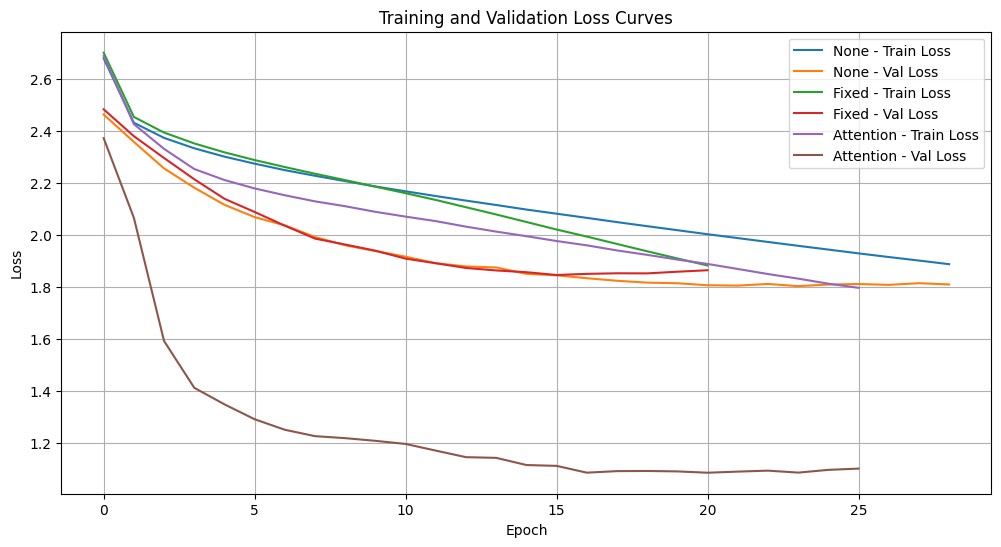

In [32]:
plot(s1_hist, s2_hist, s3_hist)

#### c. Evaluate on Test Set and Report Results in Table

In [33]:
test_results = {
    'setup': [],
    'test_loss': [],
    'test_acc': []
}

# Define new criterion
test_criterion = nn.CrossEntropyLoss(ignore_index=0)

# Setup - 1
test_results['setup'].append(1)
s1_loss, s1_acc = evaluate(s1_bst_model, test_dataloader, test_criterion)
test_results['test_loss'].append(s1_loss)
test_results['test_acc'].append(s1_acc)

# Setup - 2
test_results['setup'].append(2)
s2_loss, s2_acc = evaluate(s2_bst_model, test_dataloader, test_criterion)
test_results['test_loss'].append(s2_loss)
test_results['test_acc'].append(s2_acc)

# Setup - 3
test_results['setup'].append(3)
s3_loss, s3_acc = evaluate(s3_bst_model, test_dataloader, test_criterion)
test_results['test_loss'].append(s3_loss)
test_results['test_acc'].append(s3_acc)

pd.DataFrame(test_results)

,setup,test_loss,test_acc
0,1,1.814810,0.532902
1,2,1.870280,0.503554
2,3,1.105695,0.729248


#### d. Analyse errors

In [34]:
def find_attention_wins(model_a: Seq2Seq, model_b: Seq2Seq, loader: DataLoader, max_examples: int = 5):
    # move models to device
    model_a.to(DEVICE)
    model_b.to(DEVICE)
    
    model_a.eval()
    model_b.eval()

    # Get the dataset
    dataset: Dataset = loader.dataset

    examples = []

    with torch.no_grad():
        for src, tgt in test_dataloader:
            src = src.to(DEVICE)
            tgt = tgt.to(DEVICE)

            # Use greedy decoding / no teacher forcing
            preds_a = model_a.greedy_decode(src, max_len=tgt.size(1))
            preds_b = model_b.greedy_decode(src, max_len=tgt.size(1))

            batch_size = src.size(0)

            for i in range(batch_size):
                src_ids = src[i].cpu().tolist()
                target_ids = tgt[i].cpu().tolist()

                pred_a_ids = preds_a[i].cpu().tolist()
                pred_b_ids = preds_b[i].cpu().tolist()

                # Decode
                word, tgt_ph = dataset.decode_pair(src_ids, target_ids) # type: ignore
                _, pred_a_ph = dataset.decode_pair(src_ids, pred_a_ids) # type: ignore
                _, pred_b_ph = dataset.decode_pair(src_ids, pred_b_ids) # type: ignore

                # Get cleaned tokens
                target_clean = dataset._clean_tokens(target_ids) # type: ignore
                pred_a_clean = dataset._clean_tokens(pred_a_ids) # type: ignore
                pred_b_clean = dataset._clean_tokens(pred_b_ids) # type: ignore

                # Compare
                model_a_correct = pred_a_clean == target_clean
                model_b_correct = pred_b_clean == target_clean

                if (not model_a_correct) and model_b_correct:
                    examples.append({
                        'word': word,
                        'target': tgt_ph,
                        'model_a_prediction': pred_a_ph,
                        'model_b_prediction': pred_b_ph
                    })

                if len(examples) >= max_examples:
                    return pd.DataFrame(examples)
    return pd.DataFrame(examples)

In [35]:
# Compare s2 and s3 [worst vs best]
attn_wins_df = find_attention_wins(s2_bst_model, s3_bst_model, test_dataloader)

attn_wins_df

,word,target,model_a_prediction,model_b_prediction
0,komp,K AA1 M P,K AA1 M P ER0 Z,K AA1 M P
1,mcmorris,M AH0 K M AO1 R AH0 S,K AA1 R L IH0 NG,M AH0 K M AO1 R AH0 S
2,crisper,K R IH1 S P ER0,K R IH1 S AH0 N,K R IH1 S P ER0
3,conch,K AA1 N CH,K AA1 M,K AA1 N CH
4,flue,F L UW1,S AH1 N D ER0,F L UW1


In [ ]:
# Compare s2 and s1 [worst vs 2nd worst]
attn_wins_df = find_attention_wins(s2_bst_model, s1_bst_model, test_dataloader)

attn_wins_df

,word,target,model_a_prediction,model_b_prediction
0,roehling,R OW1 L IH0 NG,K R IH1 S T AH0 N,R OW1 L IH0 NG
1,rendell,R EH1 N D AH0 L,D IH0 S EH1 N T AH0 L,R EH1 N D AH0 L
2,codd,K AA1 D,K AA1 N AH0 L,K AA1 D
3,murrey,M ER1 IY0,M AE1 K AH0 N EY2 T IH0 D,M ER1 IY0
4,zieman,Z IY1 M AH0 N,Z IY1 M AH0,Z IY1 M AH0 N


In [37]:
# Compare s1 and s3 [2nd worst vs best]
attn_wins_df = find_attention_wins(s1_bst_model, s3_bst_model, test_dataloader)

attn_wins_df

,word,target,model_a_prediction,model_b_prediction
0,komp,K AA1 M P,K AA1 M P R AH0 M AH0 N,K AA1 M P
1,mcmorris,M AH0 K M AO1 R AH0 S,M AH0 K AA1 R V AH0 L,M AH0 K M AO1 R AH0 S
2,crisper,K R IH1 S P ER0,K R IH1 S T AH0 L,K R IH1 S P ER0
3,conch,K AA1 N CH,K AA1 N CH AH0 M,K AA1 N CH
4,flue,F L UW1,F L IH1 NG,F L UW1


### 7. Evaluation

In [38]:
def get_eval_metrics(model, loader):
    model.to(DEVICE)
    model.eval()

    # Get dataset
    dataset = loader.dataset

    total_per = 0.0
    total_exact = 0
    total_words = 0

    with torch.no_grad():
        for src, tgt in loader:
            src = src.to(DEVICE)
            tgt = tgt.to(DEVICE)

            # Greedy decoding for real test-time prediction
            preds = model.greedy_decode(
                src,
                max_len=tgt.size(1)
            )

            batch_size = src.size(0)

            for i in range(batch_size):
                pred_ids = preds[i].cpu().tolist()
                ref_ids = tgt[i].cpu().tolist()

                src_ids = src[i].cpu().tolist()

                pred_phonemes = dataset.decode_pair(src_ids, pred_ids)[1].split(" ")
                ref_phonemes = dataset.decode_pair(src_ids, ref_ids)[1].split(" ")

                distance = edit_distance(pred_phonemes, ref_phonemes)

                # Avoid division by zero, although reference should not be empty
                per = distance / max(1, len(ref_phonemes))

                total_per += per

                if pred_phonemes == ref_phonemes:
                    total_exact += 1

                total_words += 1

    avg_per = total_per / total_words
    word_accuracy = total_exact / total_words

    return avg_per, word_accuracy

In [40]:
s1_PER, s1_word_acc = get_eval_metrics(
    s1_bst_model,
    test_dataloader
)

s2_PER, s2_word_acc = get_eval_metrics(
    s2_bst_model,
    test_dataloader
)

s3_PER, s3_word_acc = get_eval_metrics(
    s3_bst_model,
    test_dataloader
)

In [44]:
test_results = pd.DataFrame({
    "Setup": [
        "No context",
        "Fixed context",
        "Attention"
    ],
    "PER": [
        s1_PER,
        s2_PER,
        s3_PER
    ],
    "Word Accuracy": [
        s1_word_acc,
        s2_word_acc,
        s3_word_acc
    ]
})

test_results

,Setup,PER,Word Accuracy
0,No context,0.855321,0.013069
1,Fixed context,0.914104,0.005366
2,Attention,0.701289,0.109832


### 8. Bottleneck [Length Analysis]

In [41]:
def get_bckt_len(word):
    length = len(word)

    if length <= 4:
        return '1-4'
    elif length <= 7:
        return '5-7'
    elif length <= 10:
        return '8-10'
    else:
        return '11+'

def bckt_len_accuracy(model, loader):
    model.to(DEVICE)
    model.eval()

    bucket_correct = {
        "1-4": 0,
        "5-7": 0,
        "8-10": 0,
        "11+": 0
    }

    bucket_total = {
        "1-4": 0,
        "5-7": 0,
        "8-10": 0,
        "11+": 0
    }

    dataset = loader.dataset

    with torch.no_grad():
        for src, tgt in loader:
            src = src.to(DEVICE)
            tgt = tgt.to(DEVICE)

            preds = model.greedy_decode(src, max_len=tgt.size(0)-1)


            for i in range(src.size(0)):
                src_ids = src[i].cpu().tolist()
                tgt_ids = tgt[i].cpu().tolist()
                preds_ids = preds[i].cpu().tolist()

                word, _ = dataset.decode_pair(src_ids, tgt_ids)

                bucket = get_bckt_len(word)

                tgt_clean = dataset._clean_tokens(tgt_ids)
                preds_clean = dataset._clean_tokens(preds_ids)

                bucket_total[bucket] += 1

                if preds_clean == tgt_clean:
                    bucket_correct[bucket] += 1

    bucket_acc = {}

    for bckt in bucket_total:
        if bucket_total[bckt] == 0:
            bucket_acc[bckt] = 0.0
        else:
            bucket_acc[bckt] = bucket_correct[bckt] / bucket_total[bckt]

    return bucket_acc

In [42]:
def plot_len_analysis(s1_bckt_acc, s2_bckt_acc, s3_bckt_acc):
    buckets = ['1-4', '5-7', '8-10', '11+']
    x = np.arange(len(buckets))

    width = 0.25

    s1_values = [s1_bckt_acc[b] for b in buckets]
    s2_values = [s2_bckt_acc[b] for b in buckets]
    s3_values = [s3_bckt_acc[b] for b in buckets]

    plt.figure(figsize=(12, 5))

    plt.bar(x-width, s1_values, width, label='No Context')
    plt.bar(x, s2_values, width, label='Fixed Context')
    plt.bar(x+width, s3_values, width, label='Attention')

    plt.xlabel("Word length bucket")
    plt.ylabel("Word accuracy")
    plt.title("Word accuracy by word length bucket")
    plt.xticks(x, buckets)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

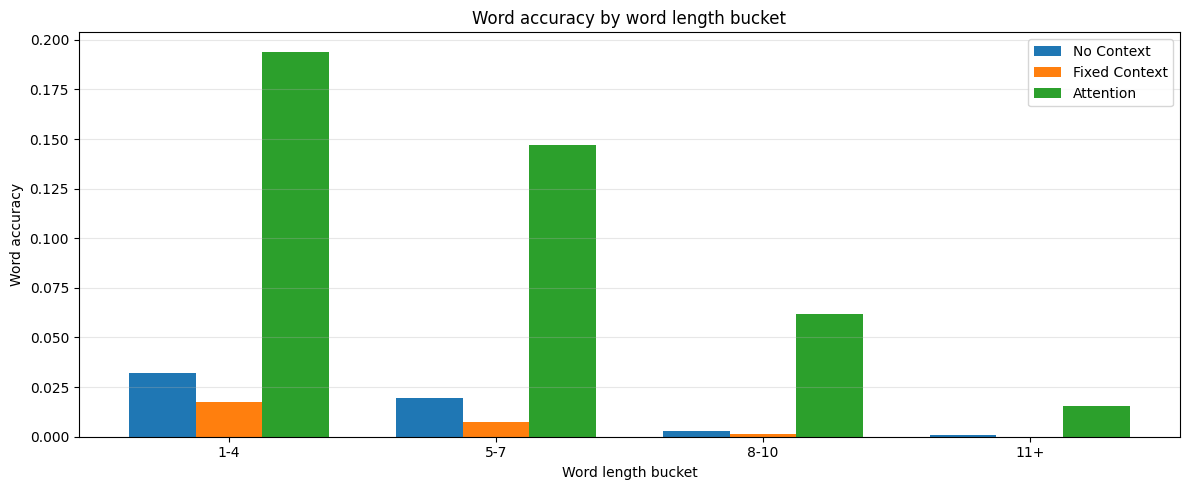

In [43]:
s1_bckt_acc = bckt_len_accuracy(s1_bst_model, test_dataloader)
s2_bckt_acc = bckt_len_accuracy(s2_bst_model, test_dataloader)
s3_bckt_acc = bckt_len_accuracy(s3_bst_model, test_dataloader)

plot_len_analysis(s1_bckt_acc, s2_bckt_acc, s3_bckt_acc)